In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

/Users/ratikpant/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Quantium Virtual Internship - Retail Strategy and
# Analytics - Task 1

In [2]:
pip install --upgrade openpyxl

Note: you may need to restart the kernel to use updated packages.


In [3]:
purchase_behaviour = pd.read_csv('/Users/ratikpant/Desktop/QUANTIUM PROJECT/QVI_purchase_behaviour.csv')
transaction_data = pd.read_excel('/Users/ratikpant/Desktop/QUANTIUM PROJECT/QVI_transaction_data.xlsx')

In [4]:
purchase_behaviour

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
...,...,...,...
72632,2370651,MIDAGE SINGLES/COUPLES,Mainstream
72633,2370701,YOUNG FAMILIES,Mainstream
72634,2370751,YOUNG FAMILIES,Premium
72635,2370961,OLDER FAMILIES,Budget


In [5]:
transaction_data

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


# data exploration and cleaniing 

# Customer Analysis

In [6]:
purchase_behaviour.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [7]:
purchase_behaviour.duplicated().sum()

0

In [8]:
purchase_behaviour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


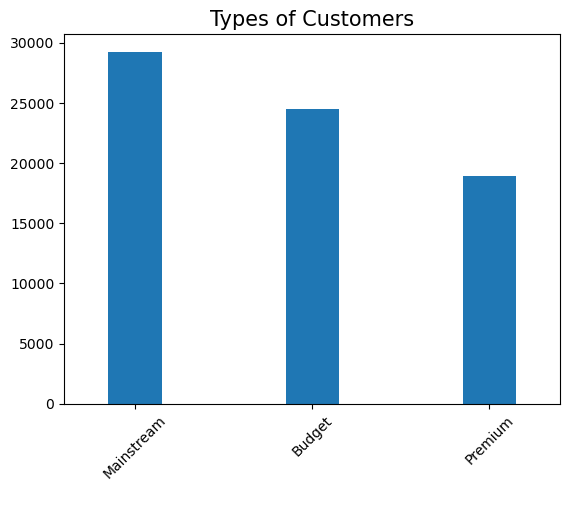

In [9]:
purchase_behaviour['PREMIUM_CUSTOMER'].value_counts().plot(kind = 'bar', width = 0.3)
plt.title("Types of Customers", fontsize =15)
plt.xticks(rotation =45)
plt.xlabel(" ")
plt.show()

# customer types in premium shopper segment

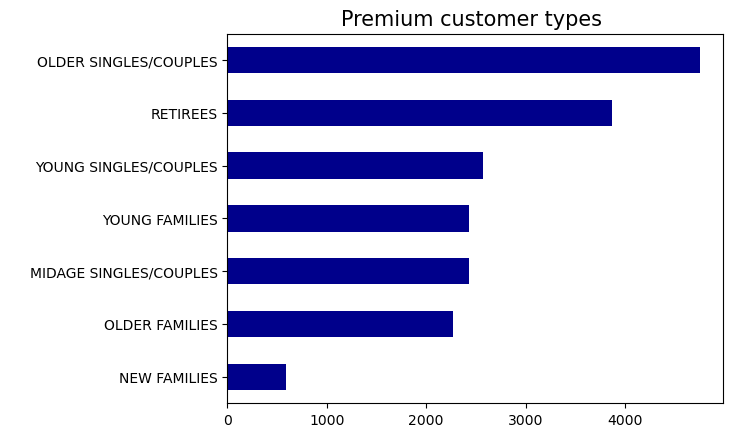

In [10]:
premium = purchase_behaviour[purchase_behaviour['PREMIUM_CUSTOMER'] == 'Premium']
premium['LIFESTAGE'].value_counts().sort_values(ascending =True).plot(kind = 'barh', color = 'darkblue')
plt.ylabel(" ")
plt.title( "Premium customer types ", fontsize =15)
plt.show()

1) older singles and couples are dominating the premium customer list

# customer types in Mainstream shopper segment

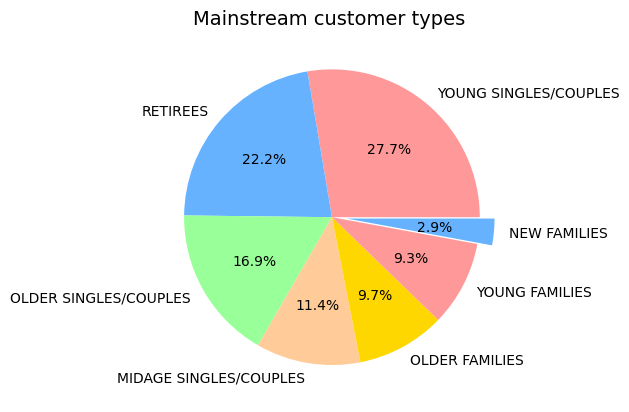

In [11]:
Mainstream = purchase_behaviour[purchase_behaviour['PREMIUM_CUSTOMER'] == 'Mainstream']
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FFD700']
explode = [0,0,0,0,0,0,0.1,]
Mainstream['LIFESTAGE'].value_counts().plot(kind = 'pie', autopct = '%1.1f%%', colors = colors, explode = explode)
plt.title("Mainstream customer types ", fontsize =14)
plt.ylabel(" ")
plt.show()

# young singles / couples , retirees and older singles / couples 

# customer types in Budget shopper segment

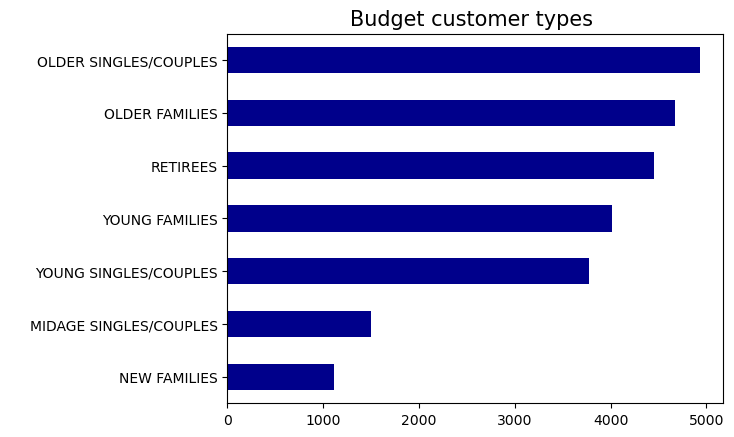

In [12]:
Budget = purchase_behaviour[purchase_behaviour['PREMIUM_CUSTOMER'] == 'Budget']
Budget['LIFESTAGE'].value_counts().sort_values(ascending =True).plot(kind = 'barh', color = 'darkblue')
plt.ylabel(" ")
plt.title( "Budget customer types ", fontsize =15)
plt.show()

# lets dive deeper into transactions data, check trends sales and different aspect of chips products.

In [13]:
transaction_data

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


# checking for missing values

In [14]:
transaction_data.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

# checking for duplicates

In [15]:
transaction_data.duplicated().sum()

1

In [16]:
transaction_data = transaction_data.drop_duplicates()

In [17]:
transaction_data

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


In [18]:
transaction_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 264835 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264835 non-null  int64  
 1   STORE_NBR       264835 non-null  int64  
 2   LYLTY_CARD_NBR  264835 non-null  int64  
 3   TXN_ID          264835 non-null  int64  
 4   PROD_NBR        264835 non-null  int64  
 5   PROD_NAME       264835 non-null  object 
 6   PROD_QTY        264835 non-null  int64  
 7   TOT_SALES       264835 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 18.2+ MB


# converting date to datetime and also in correct format for further analysis

In [19]:
transaction_data['DATE'] = pd.to_datetime(transaction_data['DATE'],origin='1899-12-30', unit='D')

In [20]:
transaction_data

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


# extracting year month and day to understand yearly , monthly and daywise trends and patterns for different chips.

In [21]:
transaction_data['MONTH'] = transaction_data['DATE'].dt.month
transaction_data['YEAR'] = transaction_data['DATE'].dt.year
transaction_data['DAY'] = transaction_data['DATE'].dt.day

In [22]:
transaction_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 264835 entries, 0 to 264835
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DATE            264835 non-null  datetime64[ns]
 1   STORE_NBR       264835 non-null  int64         
 2   LYLTY_CARD_NBR  264835 non-null  int64         
 3   TXN_ID          264835 non-null  int64         
 4   PROD_NBR        264835 non-null  int64         
 5   PROD_NAME       264835 non-null  object        
 6   PROD_QTY        264835 non-null  int64         
 7   TOT_SALES       264835 non-null  float64       
 8   MONTH           264835 non-null  int32         
 9   YEAR            264835 non-null  int32         
 10  DAY             264835 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(3), int64(5), object(1)
memory usage: 21.2+ MB


In [23]:
transaction_data['YEAR'].unique()

array([2018, 2019], dtype=int32)

In [24]:
#let's check the monthly sales trend of year 2018 and 2019.

# let's merge data to understand analyse differnt sales product and customer trends.

In [25]:
merged_data = pd.merge(purchase_behaviour,transaction_data, on='LYLTY_CARD_NBR', how='inner')

# SALES TRENDS OVER TIME

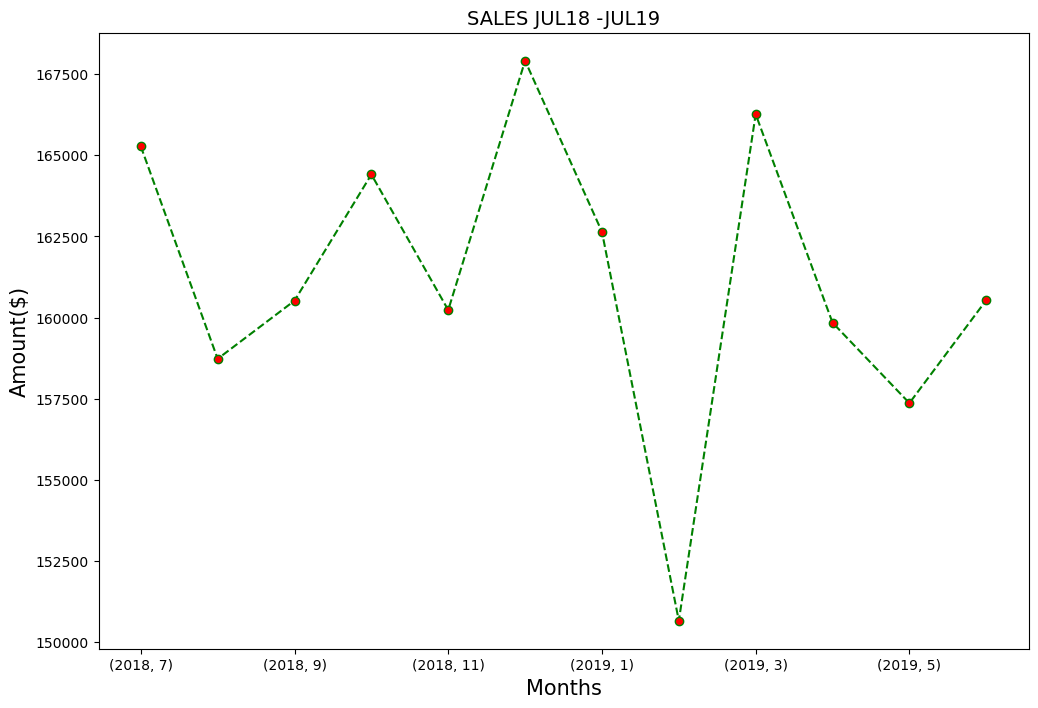

In [26]:
monthly_sales = merged_data.groupby(['YEAR', 'MONTH'])['TOT_SALES'].sum()
monthly_sales.plot(kind = 'line', figsize =(12,8), color = 'green', linestyle = '--', marker = 'o',markerfacecolor ='red')
plt.title('SALES JUL18 -JUL19', fontsize =14)
plt.ylabel("Amount($)",fontsize =15)
plt.xlabel("Months",fontsize =15)
plt.show()

# store performance

# top revenue generating stores jul18 - jul19 


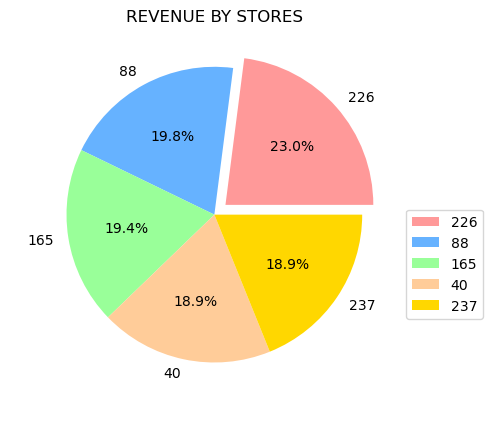

In [27]:
highest_sale_store = merged_data.groupby('STORE_NBR')['TOT_SALES'].sum().sort_values(ascending = False).head(5)
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FFD700']
explode =[0.1,0,0,0,0]
highest_sale_store.plot(kind = 'pie',autopct = '%1.1f%%', colors = colors,explode =explode)
plt.title("REVENUE BY STORES")
plt.ylabel("  ")
plt.xlabel(" ")
plt.legend(loc = 'lower left', bbox_to_anchor=(1, 0.2))
plt.show()

# Lowest chips revenue across all stores jul18- jul19

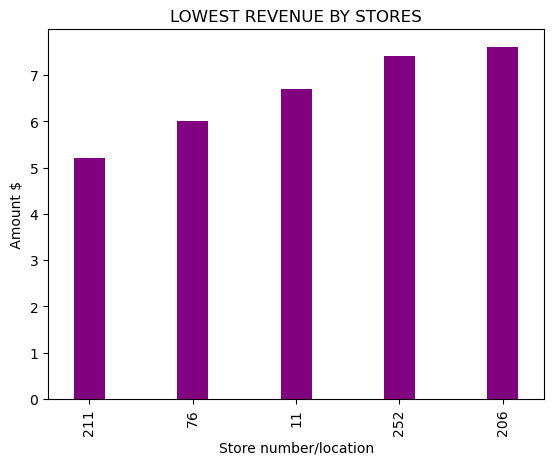

In [28]:
low_chips_sale_store = merged_data.groupby('STORE_NBR')['TOT_SALES'].sum().sort_values(ascending = True).head(5)
low_chips_sale_store.plot(kind = 'bar', color = 'purple',width = 0.3)
plt.title("LOWEST REVENUE BY STORES")
plt.ylabel(" Amount $ ")
plt.xlabel("Store number/location")
plt.show()

# lets dive in to check why is there a few dollars worth of sale and understand if it is an inconsistency.

In [29]:
store_211 = merged_data[merged_data['STORE_NBR'] == 211]

In [30]:
store_211

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,MONTH,YEAR,DAY
206257,211310,NEW FAMILIES,Budget,2019-04-11,211,210515,41,Doritos Salsa Mild 300g,1,2.6,4,2019,11
206258,211332,OLDER FAMILIES,Budget,2018-07-16,211,210516,101,Doritos Salsa Medium 300g,1,2.6,7,2018,16


# this explains that these stores have vey little data to run and understand any patterns of less sales.

# Let's check best products in the store 226 that has given maximum sale in the period jul18 -jul19

In [31]:
store_226 = merged_data[merged_data['STORE_NBR'] == 226]
store_226

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,MONTH,YEAR,DAY
221624,226000,OLDER FAMILIES,Premium,2018-08-19,226,226201,4,Dorito Corn Chp Supreme 380g,200,650.0,8,2018,19
221625,226000,OLDER FAMILIES,Premium,2019-05-20,226,226210,4,Dorito Corn Chp Supreme 380g,200,650.0,5,2019,20
221626,226002,OLDER SINGLES/COUPLES,Budget,2018-10-14,226,226213,16,Smiths Crinkle Chips Salt & Vinegar 330g,2,11.4,10,2018,14
221627,226002,OLDER SINGLES/COUPLES,Budget,2018-12-03,226,226214,71,Twisties Cheese Burger 250g,2,8.6,12,2018,3
221628,226002,OLDER SINGLES/COUPLES,Budget,2019-01-20,226,226215,75,Cobs Popd Sea Salt Chips 110g,2,7.6,1,2019,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...
223641,226383,OLDER SINGLES/COUPLES,Premium,2018-08-14,226,228280,17,Kettle Sensations BBQ&Maple 150g,1,4.6,8,2018,14
223642,226383,OLDER SINGLES/COUPLES,Premium,2018-07-07,226,228278,17,Kettle Sensations BBQ&Maple 150g,2,9.2,7,2018,7
223643,226383,OLDER SINGLES/COUPLES,Premium,2018-07-13,226,228279,93,Doritos Corn Chip Southern Chicken 150g,2,7.8,7,2018,13
223644,226383,OLDER SINGLES/COUPLES,Premium,2019-02-11,226,228281,32,Kettle Sea Salt And Vinegar 175g,2,10.8,2,2019,11


In [32]:
grouped_226 = store_226.groupby('PROD_NAME')[['PROD_QTY', 'TOT_SALES']].sum()
grouped_226

,PROD_QTY,TOT_SALES
PROD_NAME,,
Cheezels Cheese 330g,58,330.60
Cobs Popd Sea Salt Chips 110g,78,296.40
Cobs Popd Sour Crm &Chives Chips 110g,70,266.00
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g,74,281.20
Dorito Corn Chp Supreme 380g,479,1803.75
Doritos Cheese Supreme 330g,52,296.40
Doritos Corn Chip Mexican Jalapeno 150g,76,296.40
Doritos Corn Chip Southern Chicken 150g,48,187.20
Doritos Corn Chips Cheese Supreme 170g,46,202.40


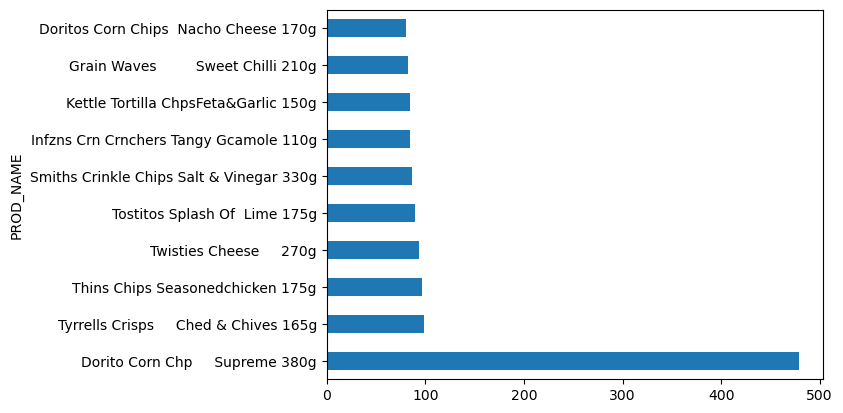

In [33]:
top_quant = grouped_226['PROD_QTY'].nlargest(10).plot(kind = 'barh')
plt.show()

# DORITO CORN CHP SEEMS TO HAVE BEEN THE MOST PURCHASED PRODUCT. BEST-SELLER

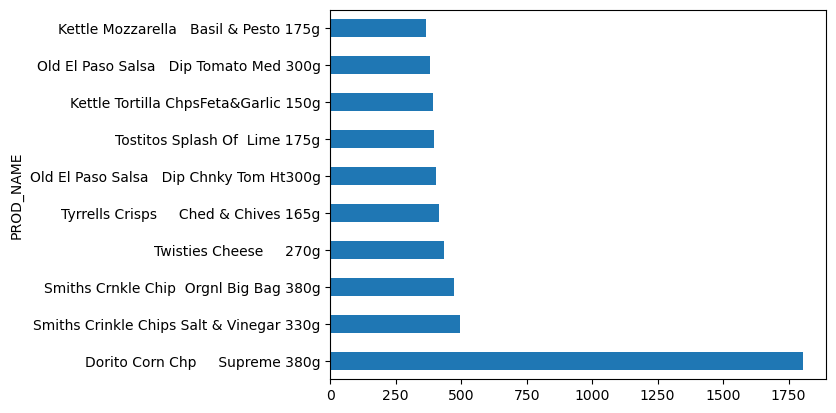

In [34]:
TO_REV =grouped_226['TOT_SALES'].nlargest(10).plot(kind = 'barh')

# #interesting to see if there were promotions run on this product in store 226 for a large part. Due to data limitation we cannot find it though.

# let's define few business metrics: total_spend- amount spent by that customer in 2018jul -2019jul
# avg_spend - average spend per customer per loyalty number
# product bought - total products bought per loyalty number 2018jul to 2019 jul
# price per product - price of the product at the time of purchase
# pack size - packsize of the product
# brand name- name of the chip brand


In [35]:
merged_data['total_spend'] = merged_data.groupby('LYLTY_CARD_NBR')['TOT_SALES'].transform('sum')
merged_data['monthly_sales'] = merged_data.groupby('MONTH')['TOT_SALES'].transform('sum').round(2)
merged_data['product_Bought'] = merged_data.groupby('LYLTY_CARD_NBR')['PROD_QTY'].transform('sum')
merged_data['price_per_product'] = merged_data['TOT_SALES'] / merged_data['PROD_QTY']
merged_data

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,MONTH,YEAR,DAY,total_spend,monthly_sales,product_Bought,price_per_product
0,1000,YOUNG SINGLES/COUPLES,Premium,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,10,2018,17,6.0,164409.7,2,3.0
1,1002,YOUNG SINGLES/COUPLES,Mainstream,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,9,2018,16,2.7,160522.0,1,2.7
2,1003,YOUNG FAMILIES,Budget,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,3,2019,7,6.6,166265.2,2,3.6
3,1003,YOUNG FAMILIES,Budget,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,3,2019,8,6.6,166265.2,2,3.0
4,1004,OLDER SINGLES/COUPLES,Mainstream,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,11,2018,2,1.9,160233.7,1,1.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264830,2370701,YOUNG FAMILIES,Mainstream,2018-12-08,88,240378,24,Grain Waves Sweet Chilli 210g,2,7.2,12,2018,8,7.2,167913.4,2,3.6
264831,2370751,YOUNG FAMILIES,Premium,2018-10-01,88,240394,60,Kettle Tortilla ChpsFeta&Garlic 150g,2,9.2,10,2018,1,9.2,164409.7,2,4.6
264832,2370961,OLDER FAMILIES,Budget,2018-10-24,88,240480,70,Tyrrells Crisps Lightly Salted 165g,2,8.4,10,2018,24,18.6,164409.7,4,4.2
264833,2370961,OLDER FAMILIES,Budget,2018-10-27,88,240481,65,Old El Paso Salsa Dip Chnky Tom Ht300g,2,10.2,10,2018,27,18.6,164409.7,4,5.1


In [36]:
#extracting pack size from product name using regex(regular expression)

In [37]:
merged_data['PACK_SIZE'] = merged_data['PROD_NAME'].str.extract(r'(\d+\s?[gGmMlL]+)')
merged_data

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,MONTH,YEAR,DAY,total_spend,monthly_sales,product_Bought,price_per_product,PACK_SIZE
0,1000,YOUNG SINGLES/COUPLES,Premium,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,10,2018,17,6.0,164409.7,2,3.0,175g
1,1002,YOUNG SINGLES/COUPLES,Mainstream,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,9,2018,16,2.7,160522.0,1,2.7,150g
2,1003,YOUNG FAMILIES,Budget,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,3,2019,7,6.6,166265.2,2,3.6,210G
3,1003,YOUNG FAMILIES,Budget,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,3,2019,8,6.6,166265.2,2,3.0,175g
4,1004,OLDER SINGLES/COUPLES,Mainstream,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,11,2018,2,1.9,160233.7,1,1.9,160g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264830,2370701,YOUNG FAMILIES,Mainstream,2018-12-08,88,240378,24,Grain Waves Sweet Chilli 210g,2,7.2,12,2018,8,7.2,167913.4,2,3.6,210g
264831,2370751,YOUNG FAMILIES,Premium,2018-10-01,88,240394,60,Kettle Tortilla ChpsFeta&Garlic 150g,2,9.2,10,2018,1,9.2,164409.7,2,4.6,150g
264832,2370961,OLDER FAMILIES,Budget,2018-10-24,88,240480,70,Tyrrells Crisps Lightly Salted 165g,2,8.4,10,2018,24,18.6,164409.7,4,4.2,165g
264833,2370961,OLDER FAMILIES,Budget,2018-10-27,88,240481,65,Old El Paso Salsa Dip Chnky Tom Ht300g,2,10.2,10,2018,27,18.6,164409.7,4,5.1,300g


In [38]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264835 entries, 0 to 264834
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   LYLTY_CARD_NBR     264835 non-null  int64         
 1   LIFESTAGE          264835 non-null  object        
 2   PREMIUM_CUSTOMER   264835 non-null  object        
 3   DATE               264835 non-null  datetime64[ns]
 4   STORE_NBR          264835 non-null  int64         
 5   TXN_ID             264835 non-null  int64         
 6   PROD_NBR           264835 non-null  int64         
 7   PROD_NAME          264835 non-null  object        
 8   PROD_QTY           264835 non-null  int64         
 9   TOT_SALES          264835 non-null  float64       
 10  MONTH              264835 non-null  int32         
 11  YEAR               264835 non-null  int32         
 12  DAY                264835 non-null  int32         
 13  total_spend        264835 non-null  float64 

# converting the packsize into numbers for plotting the distribution.

In [39]:
merged_data['pack_size_num'] = merged_data['PACK_SIZE'].str.extract(r'(\d+)').astype(int)

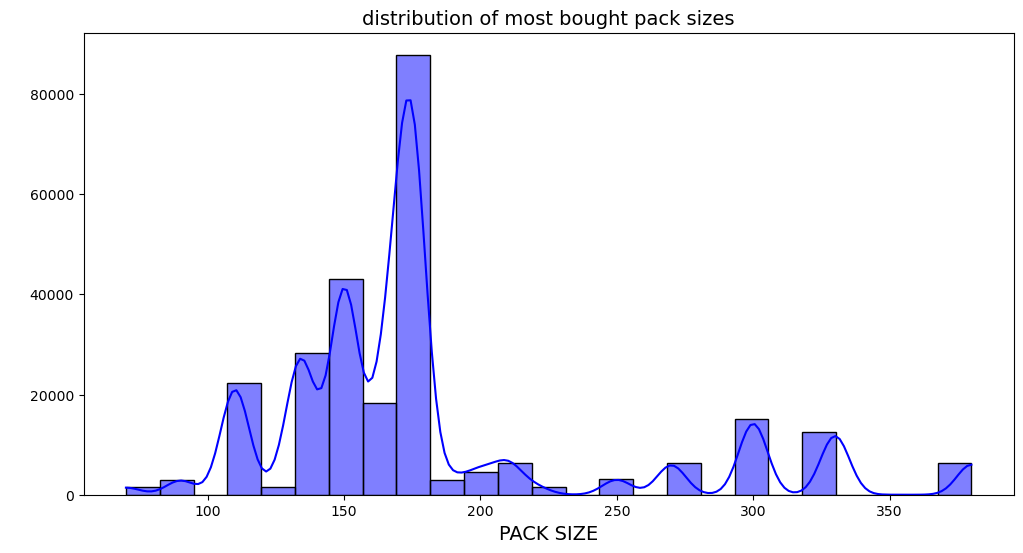

In [40]:
plt.figure(figsize = (12,6))
sns.histplot(data = merged_data , x = 'pack_size_num', bins =25, kde = True, color = 'blue')
plt.title("distribution of most bought pack sizes", fontsize = 14)
plt.xlabel("PACK SIZE", fontsize =14)
plt.ylabel(" ")
plt.show()


# this could help us in extracting the low sizes which are not being sold and pull up their brand.

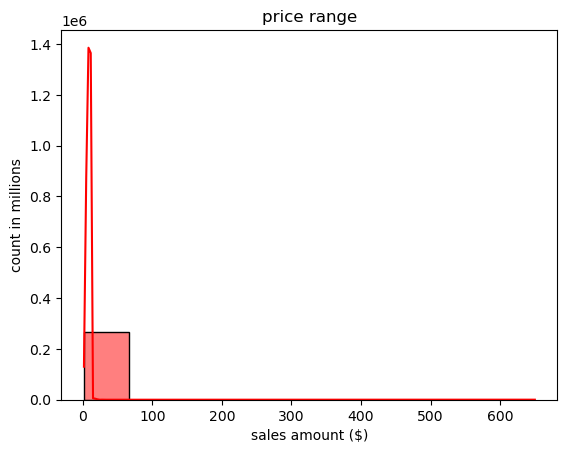

In [41]:
#lets understand the price spent distribution on chips all across year 2018jul 2019jul
sns.histplot(merged_data['TOT_SALES'], bins = 10, kde = True, color = 'red')
plt.title("price range")
plt.ylabel("count in millions")
plt.xlabel('sales amount ($)')
plt.show()

# the distribution shows the data is heavily right skewed. Let's understand why and look for anomalies.

In [42]:
merged_data[merged_data['TOT_SALES'] > 30]

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,MONTH,YEAR,DAY,total_spend,monthly_sales,product_Bought,price_per_product,PACK_SIZE,pack_size_num
221624,226000,OLDER FAMILIES,Premium,2018-08-19,226,226201,4,Dorito Corn Chp Supreme 380g,200,650.0,8,2018,19,1300.0,158731.05,400,3.25,380g,380
221625,226000,OLDER FAMILIES,Premium,2019-05-20,226,226210,4,Dorito Corn Chp Supreme 380g,200,650.0,5,2019,20,1300.0,157367.65,400,3.25,380g,380


# there are only 2 single purchases over 30, which appears to be an anomaly. we will remove these 2 rows from the group.

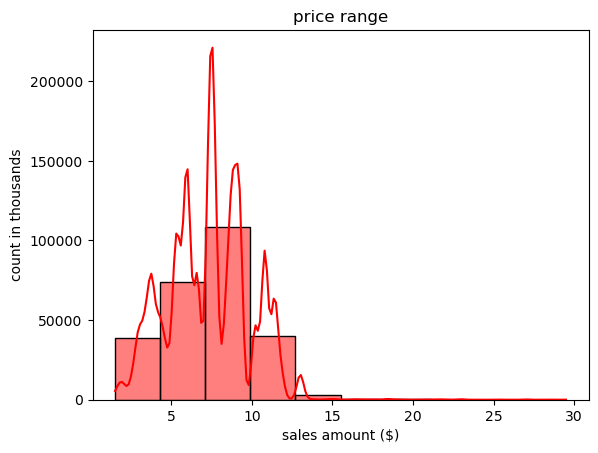

In [43]:
#storing dataframe without those 2 transactions
merged_data = merged_data[merged_data['TOT_SALES'] < 30]
#lets understand the price spent distribution on chips all across year 2018jul 2019jul
sns.histplot(merged_data['TOT_SALES'], bins = 10, kde = True, color = 'red')
plt.title("price range")
plt.ylabel("count in thousands")
plt.xlabel('sales amount ($)')
plt.show()

In [44]:
#the distribution now looks alright now.


# 2019 sales

In [45]:
year_19 = merged_data[merged_data['YEAR'] ==2019]

# top 10 products(best -sellers) bought each months across all stores 2019

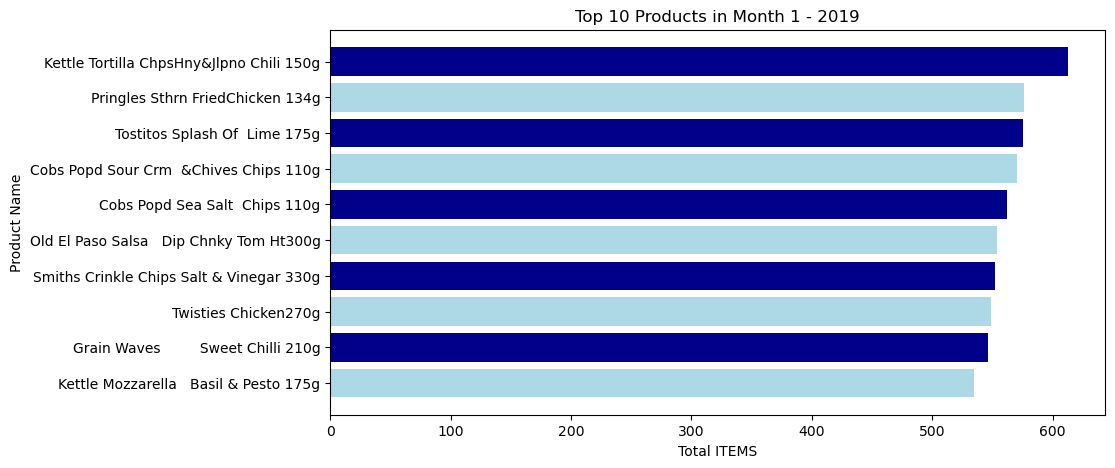

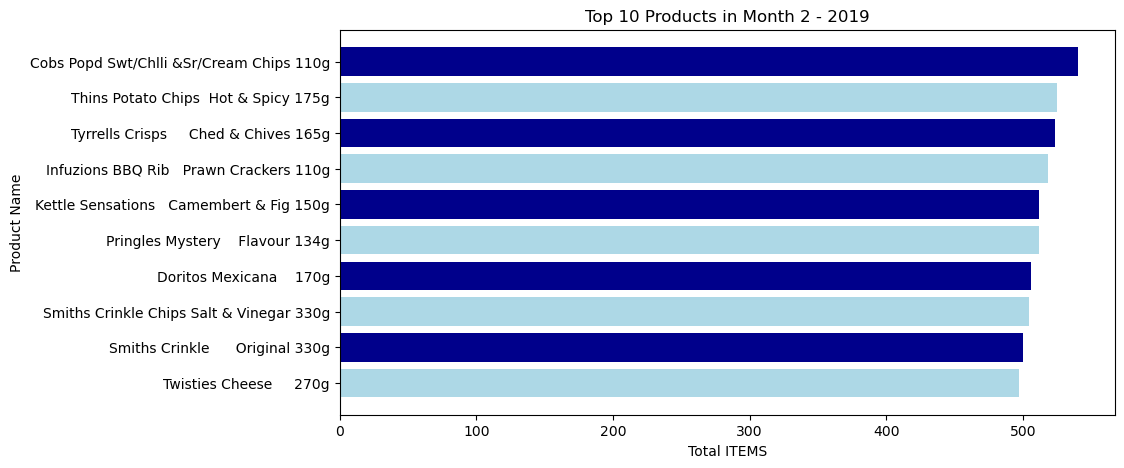

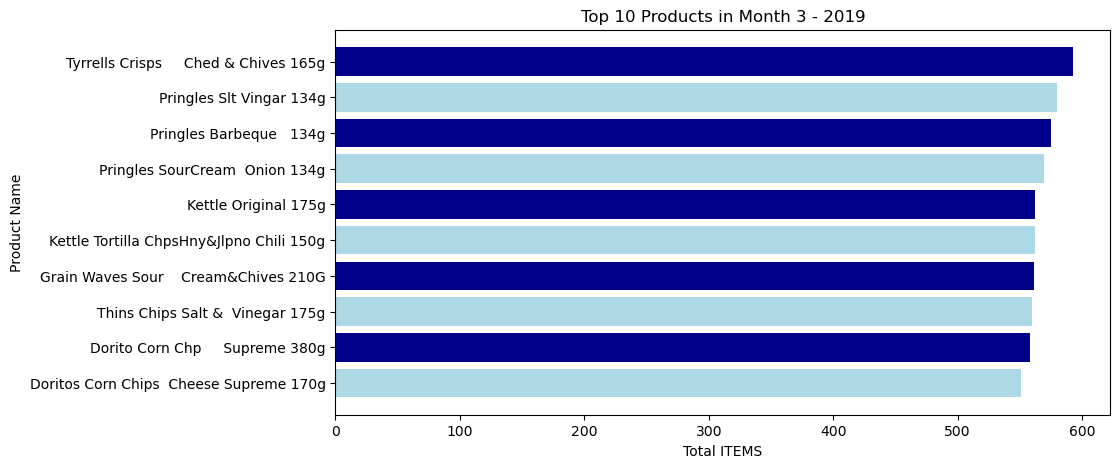

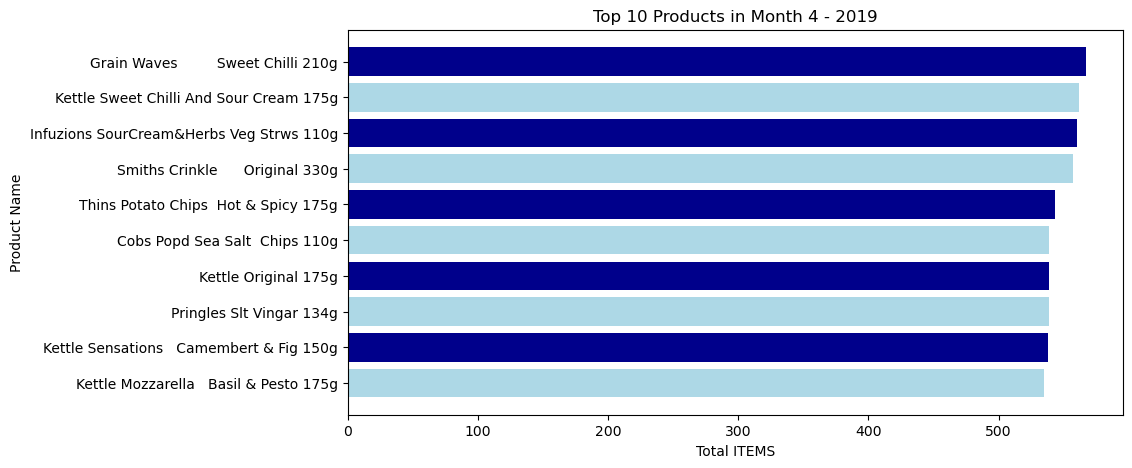

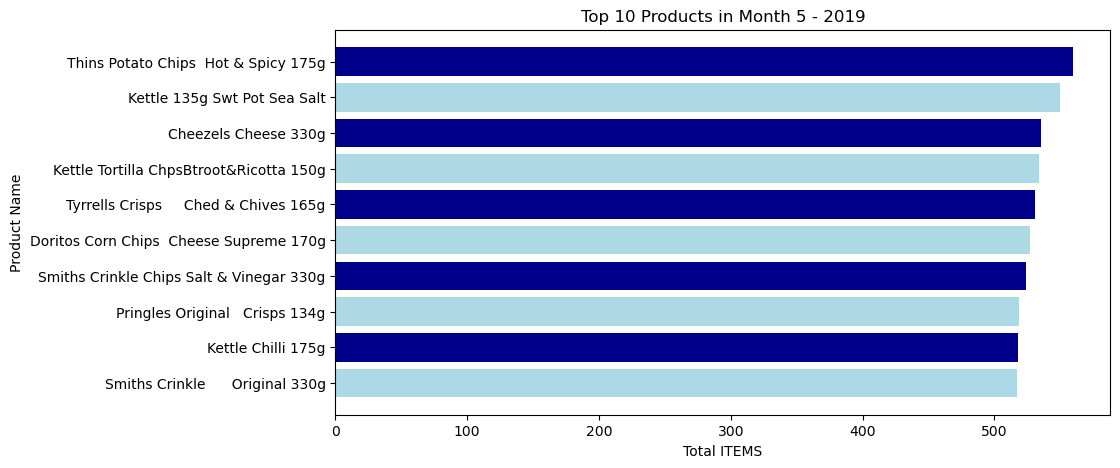

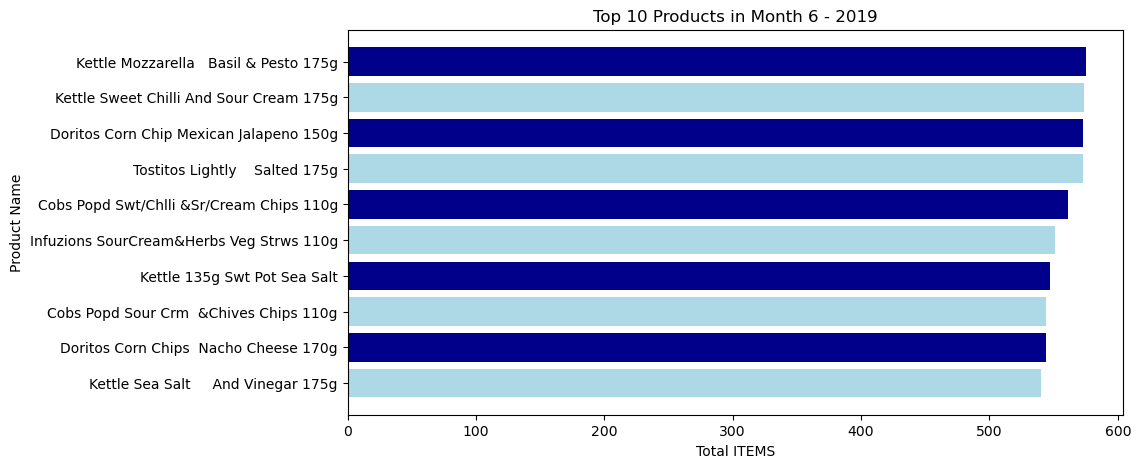

In [46]:
month = sorted(year_19['MONTH'].unique())  # Get unique months and sort them

for month in month:
    month_data = year_19[year_19['MONTH'] == month]
    top_product = month_data.groupby('PROD_NAME')['PROD_QTY'].sum().nlargest(10).reset_index()

    # Plot
    plt.figure(figsize=(10, 5))
    plt.barh(top_product['PROD_NAME'], top_product['PROD_QTY'], color=['darkblue','lightblue' ])
    plt.xlabel("Total ITEMS")
    plt.ylabel("Product Name")
    plt.title(f"Top 10 Products in Month {month} - 2019")
    plt.gca().invert_yaxis()
    plt.show()

# top 10 most revenue generating products across 2019 across all stores

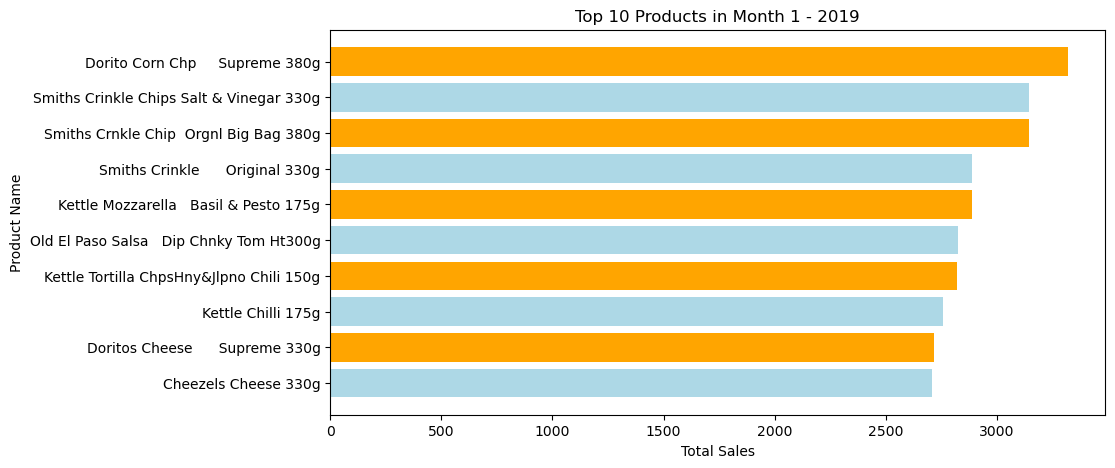

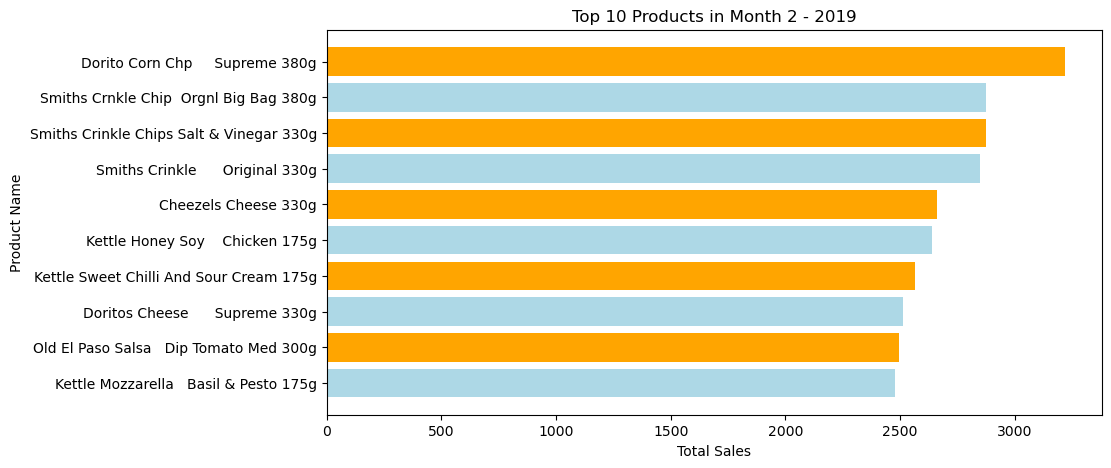

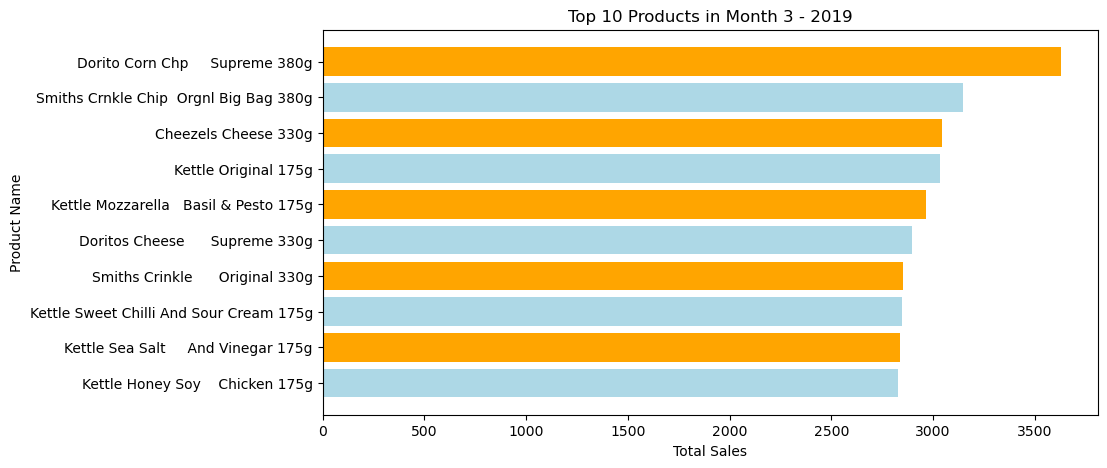

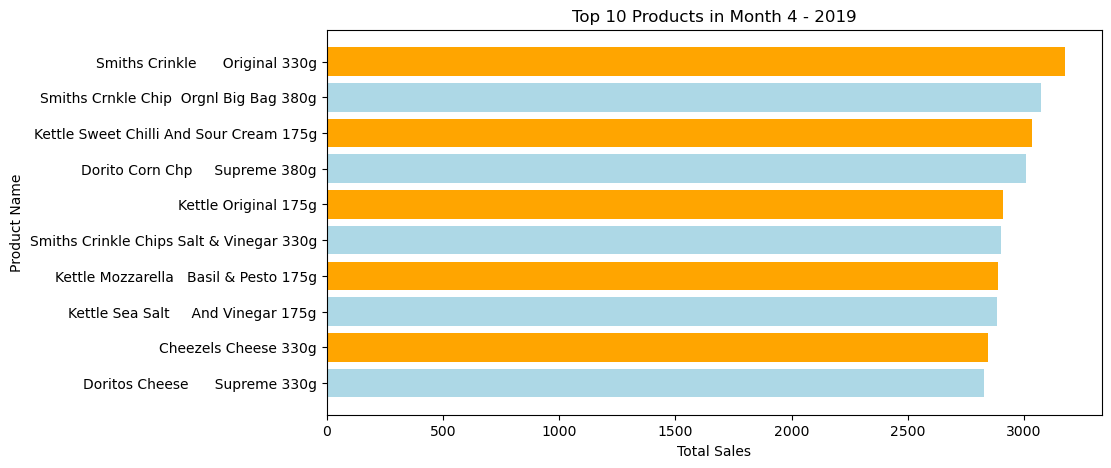

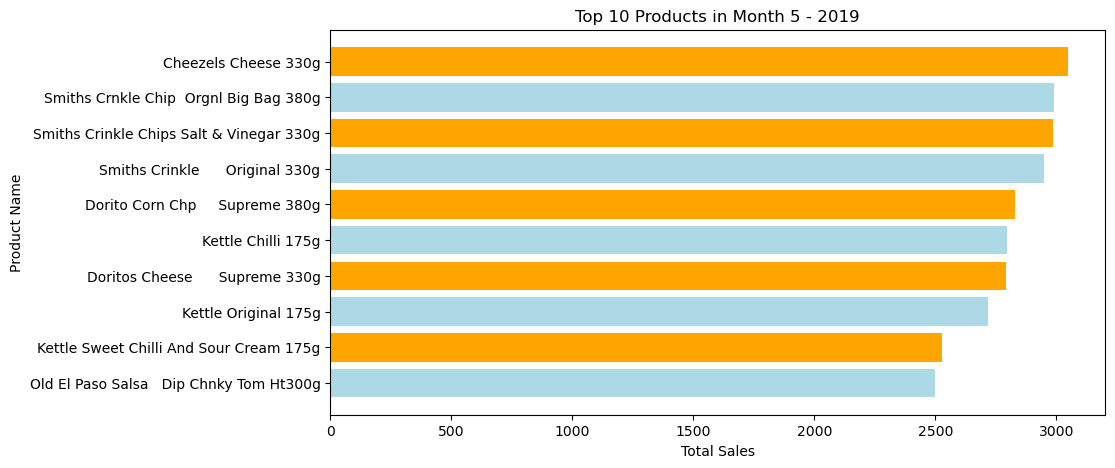

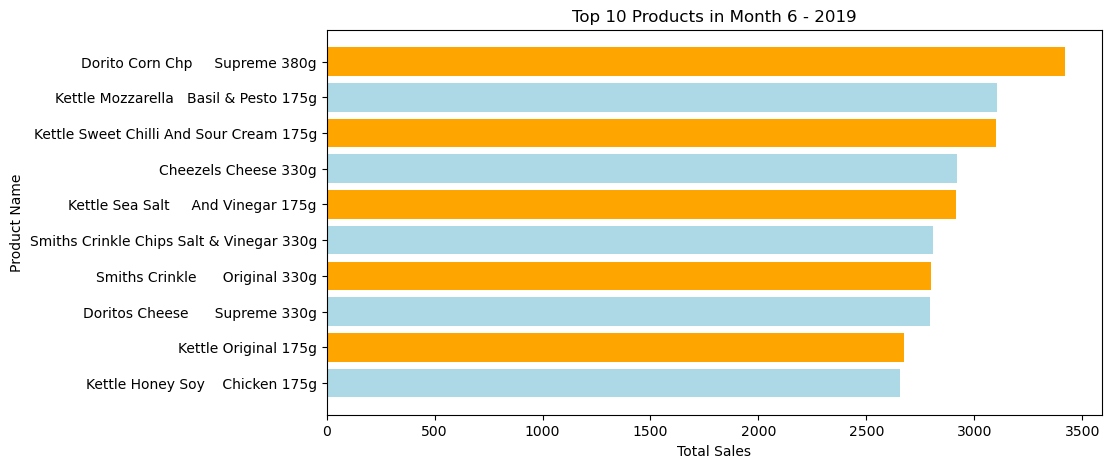

In [47]:
months = sorted(year_19['MONTH'].unique())  

for month in months:
    month_data = year_19[year_19['MONTH'] == month]
    top_products = month_data.groupby('PROD_NAME')['TOT_SALES'].sum().nlargest(10).reset_index()

    plt.figure(figsize=(10, 5))
    plt.barh(top_products['PROD_NAME'], top_products['TOT_SALES'], color =['orange', 'lightblue'])
    plt.xlabel("Total Sales")
    plt.ylabel("Product Name")
    plt.title(f"Top 10 Products in Month {month} - 2019")
    plt.gca().invert_yaxis()
    plt.show()

# 2018 sales

In [48]:
year_18 = merged_data[merged_data['YEAR'] ==2018 ]

# top 10 products(best -sellers) bought each months across all stores 2018

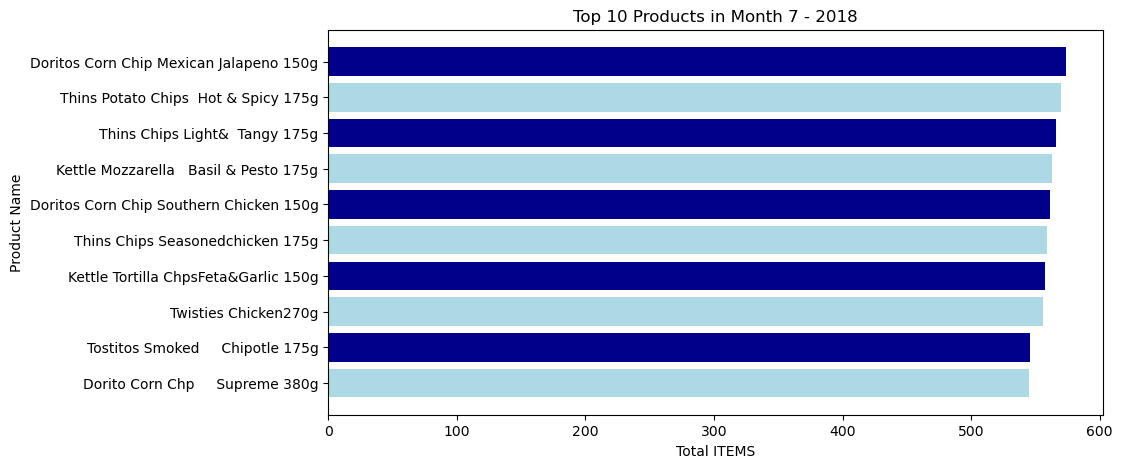

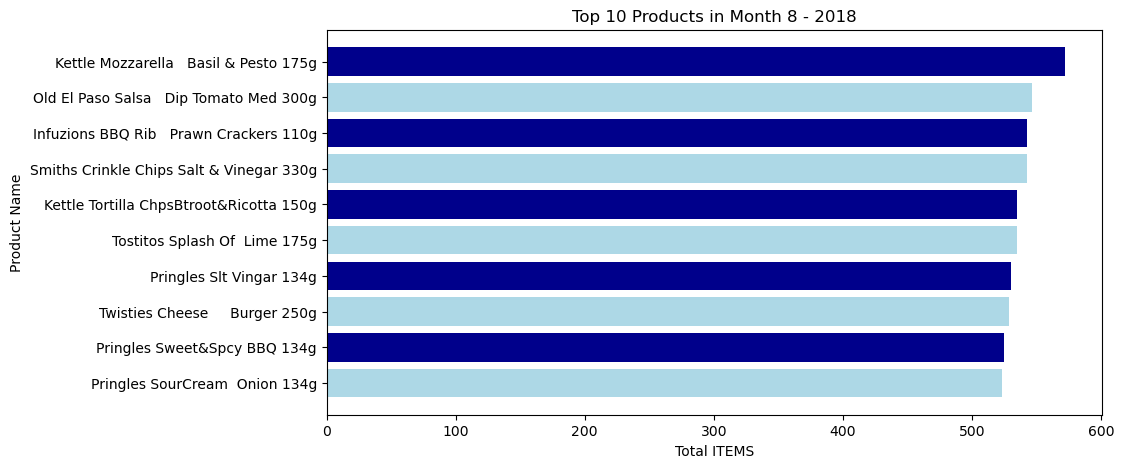

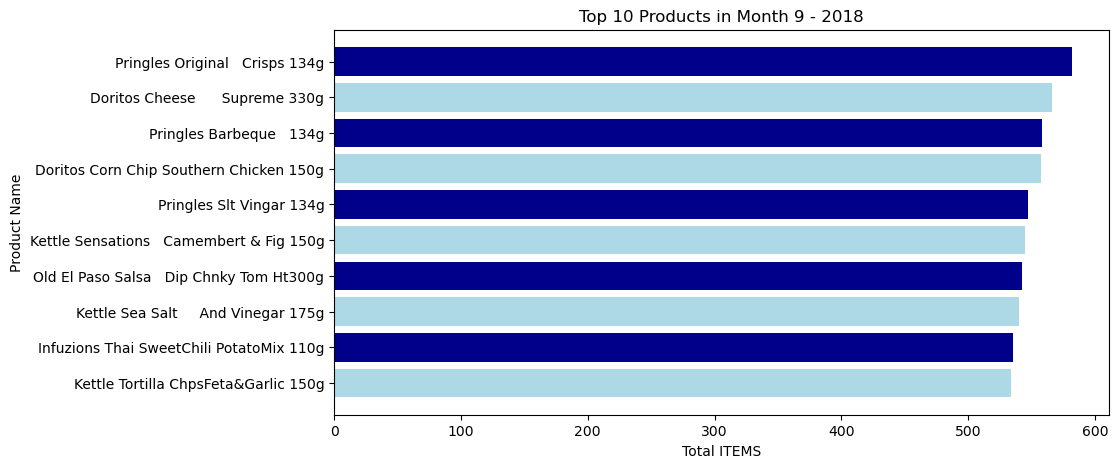

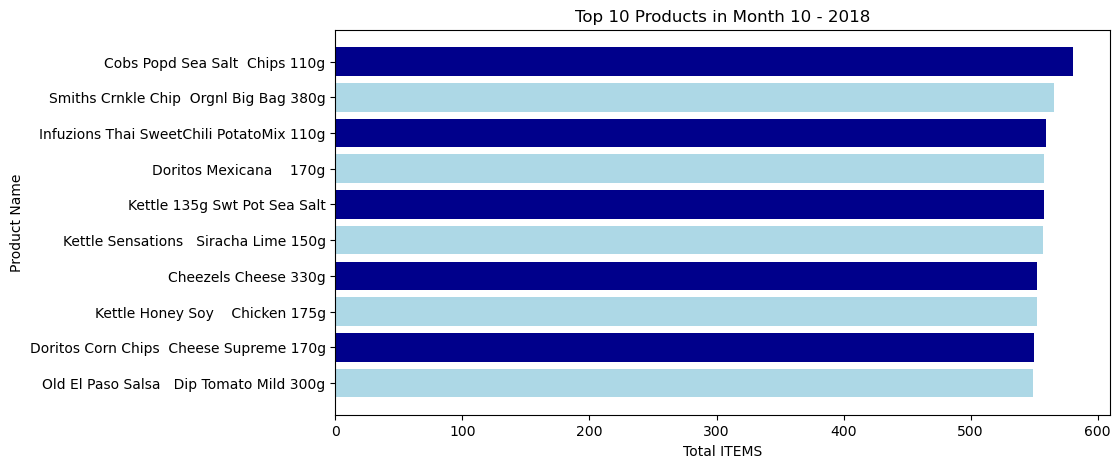

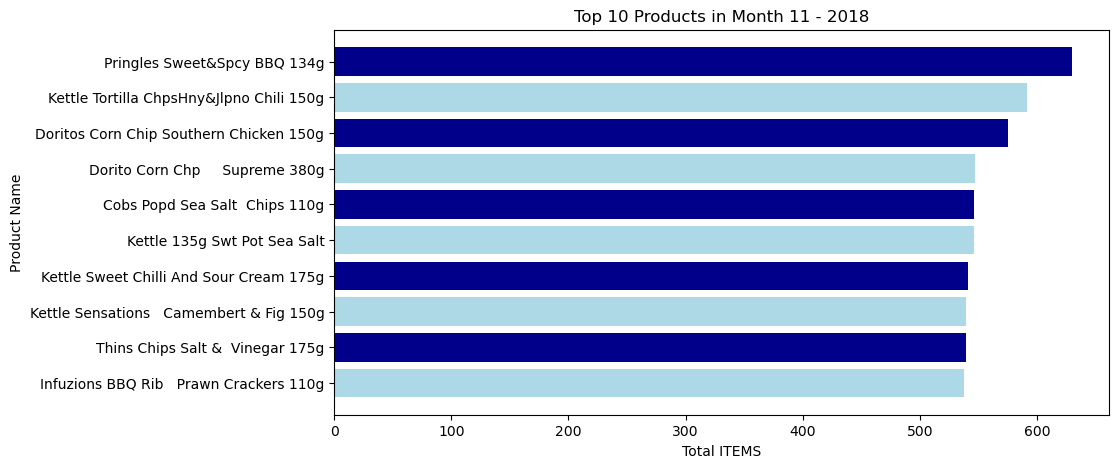

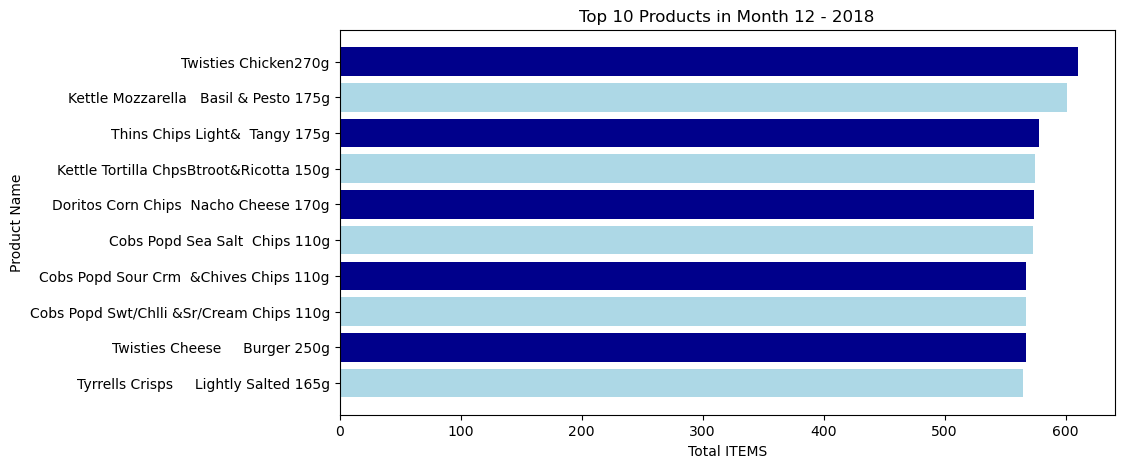

In [49]:
month = sorted(year_18['MONTH'].unique())  # Get unique months and sort them

for month in month:
    month_data = year_18[year_18['MONTH'] == month]
    top_product = month_data.groupby('PROD_NAME')['PROD_QTY'].sum().nlargest(10).reset_index()

    # Plot
    plt.figure(figsize=(10, 5))
    plt.barh(top_product['PROD_NAME'], top_product['PROD_QTY'], color=['darkblue','lightblue' ])
    plt.xlabel("Total ITEMS")
    plt.ylabel("Product Name")
    plt.title(f"Top 10 Products in Month {month} - 2018")
    plt.gca().invert_yaxis()
    plt.show()

# top 10 most revenue generating products across 2018 across all stores

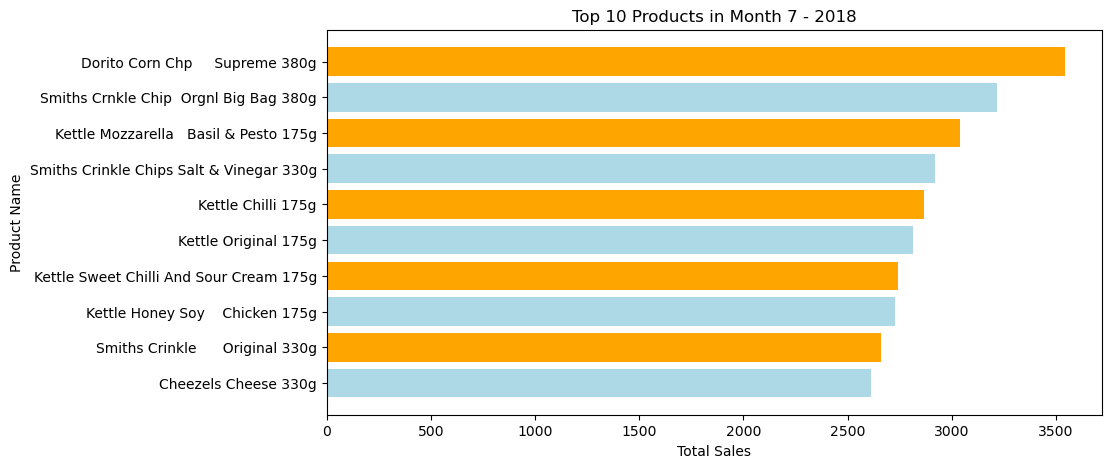

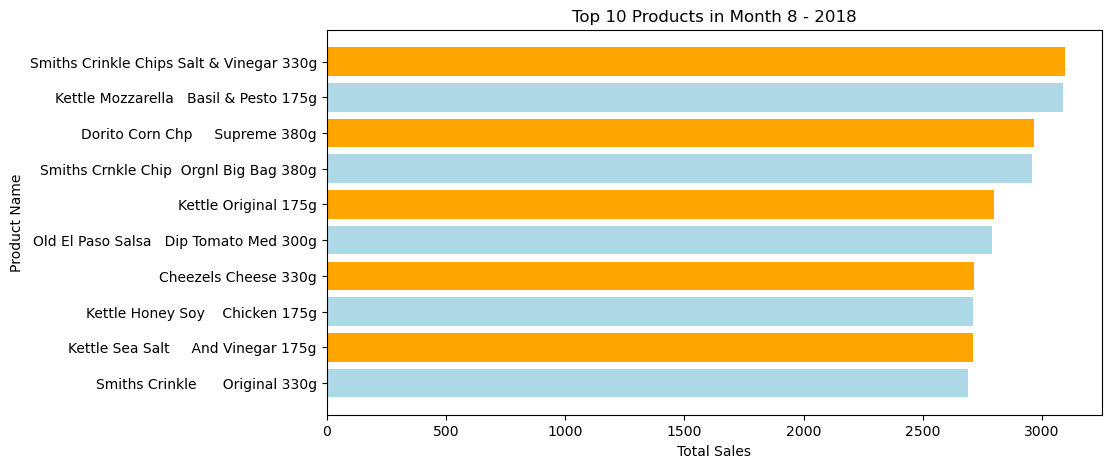

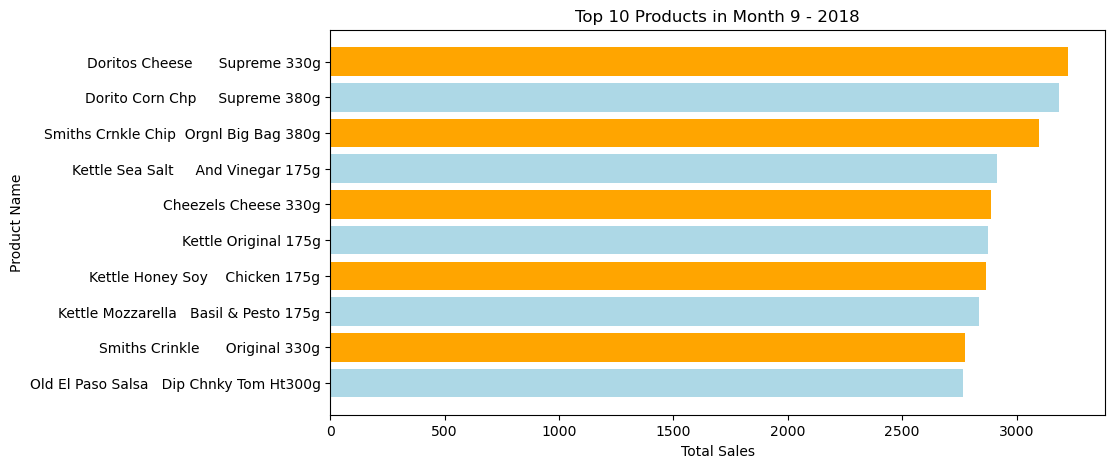

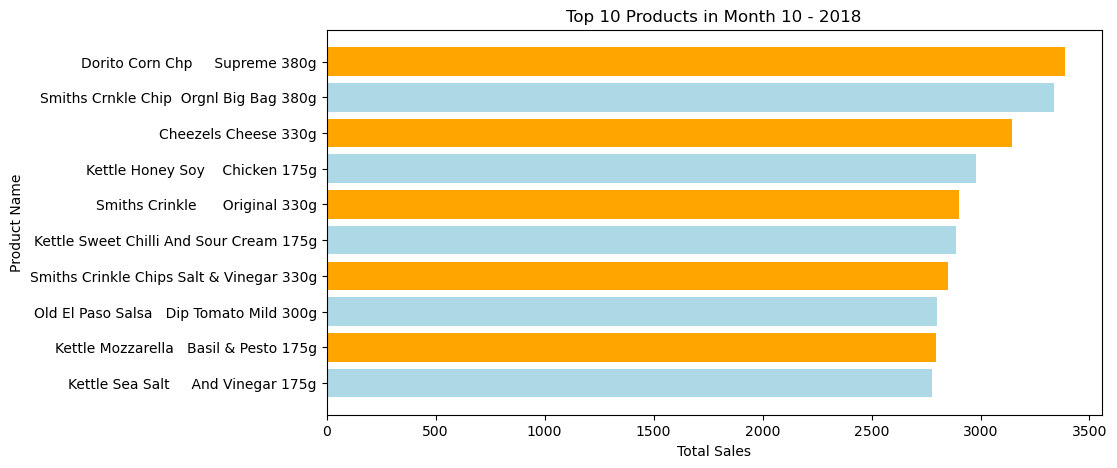

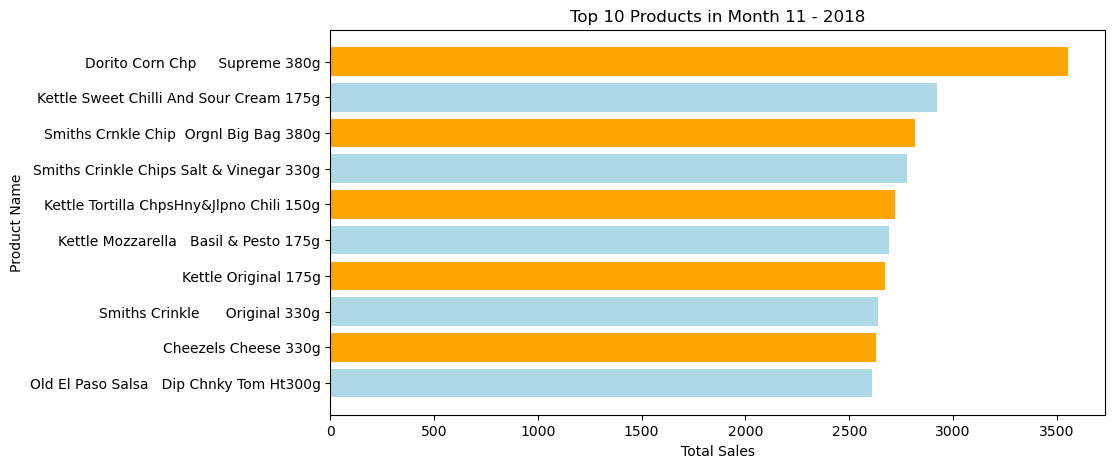

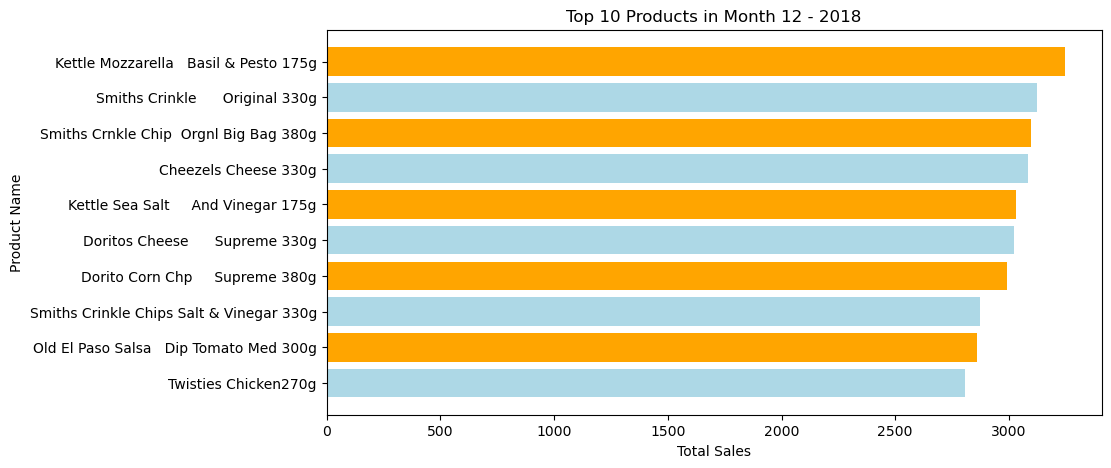

In [50]:
months = sorted(year_18['MONTH'].unique())  

for month in months:
    month_data = year_18[year_18['MONTH'] == month]
    top_products = month_data.groupby('PROD_NAME')['TOT_SALES'].sum().nlargest(10).reset_index()

    plt.figure(figsize=(10, 5))
    plt.barh(top_products['PROD_NAME'], top_products['TOT_SALES'], color =['orange', 'lightblue'])
    plt.xlabel("Total Sales")
    plt.ylabel("Product Name")
    plt.title(f"Top 10 Products in Month {month} - 2018")
    plt.gca().invert_yaxis()
    plt.show()

# Metrics we have developed such as total spends: cumulative amount spent across 1 year on chips. avg_spend : average spend per customer per loyalty number can give us insights on customers and allow cx specific marketing approach.

# we could run promotions and target specific customers types: for example: we have to give special discounts to people who is spending lower than avg spending.

# CX type spending on chips

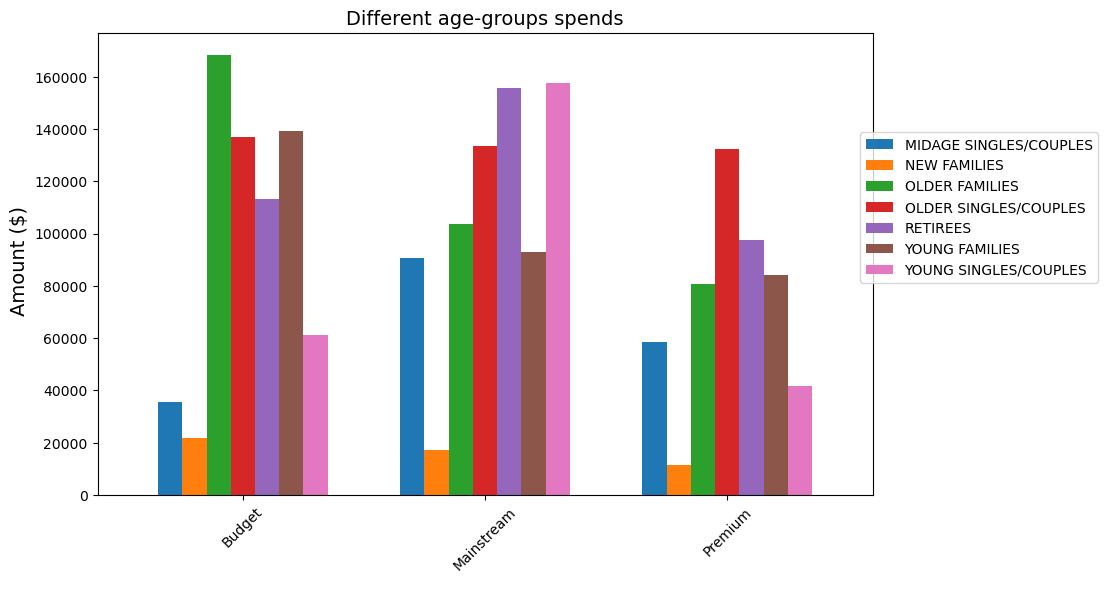

In [51]:

cx_type_spend = merged_data.groupby(['PREMIUM_CUSTOMER', 'LIFESTAGE'])['TOT_SALES'].sum().unstack().plot(kind ='bar'
                                                               ,width =0.7 ,figsize =(10,6))
plt.title("Different age-groups spends", fontsize =14)
plt.xlabel(" ")
plt.xticks(rotation = 45)
plt.ylabel(" Amount ($)", fontsize =14)
plt.legend(loc = 'upper right',bbox_to_anchor=(1.3, 0.8))
plt.show()



# Budget Category: Older families and older singles /couples tend to spend more on chips while midage singles/ couples and new families tend to spend lesser. 

# Mainstream Category: Young singles/ couples and retirees are most number of buyers in this category while new families spends the least on chips.

# Premium Category: older singles/ couples dominate in premium category while ne families remains docile in buying chips.

In [52]:
merged_data

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,MONTH,YEAR,DAY,total_spend,monthly_sales,product_Bought,price_per_product,PACK_SIZE,pack_size_num
0,1000,YOUNG SINGLES/COUPLES,Premium,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,10,2018,17,6.0,164409.7,2,3.0,175g,175
1,1002,YOUNG SINGLES/COUPLES,Mainstream,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,9,2018,16,2.7,160522.0,1,2.7,150g,150
2,1003,YOUNG FAMILIES,Budget,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,3,2019,7,6.6,166265.2,2,3.6,210G,210
3,1003,YOUNG FAMILIES,Budget,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,3,2019,8,6.6,166265.2,2,3.0,175g,175
4,1004,OLDER SINGLES/COUPLES,Mainstream,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,11,2018,2,1.9,160233.7,1,1.9,160g,160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264830,2370701,YOUNG FAMILIES,Mainstream,2018-12-08,88,240378,24,Grain Waves Sweet Chilli 210g,2,7.2,12,2018,8,7.2,167913.4,2,3.6,210g,210
264831,2370751,YOUNG FAMILIES,Premium,2018-10-01,88,240394,60,Kettle Tortilla ChpsFeta&Garlic 150g,2,9.2,10,2018,1,9.2,164409.7,2,4.6,150g,150
264832,2370961,OLDER FAMILIES,Budget,2018-10-24,88,240480,70,Tyrrells Crisps Lightly Salted 165g,2,8.4,10,2018,24,18.6,164409.7,4,4.2,165g,165
264833,2370961,OLDER FAMILIES,Budget,2018-10-27,88,240481,65,Old El Paso Salsa Dip Chnky Tom Ht300g,2,10.2,10,2018,27,18.6,164409.7,4,5.1,300g,300


In [53]:
merged_data

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,MONTH,YEAR,DAY,total_spend,monthly_sales,product_Bought,price_per_product,PACK_SIZE,pack_size_num
0,1000,YOUNG SINGLES/COUPLES,Premium,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,10,2018,17,6.0,164409.7,2,3.0,175g,175
1,1002,YOUNG SINGLES/COUPLES,Mainstream,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,9,2018,16,2.7,160522.0,1,2.7,150g,150
2,1003,YOUNG FAMILIES,Budget,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,3,2019,7,6.6,166265.2,2,3.6,210G,210
3,1003,YOUNG FAMILIES,Budget,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,3,2019,8,6.6,166265.2,2,3.0,175g,175
4,1004,OLDER SINGLES/COUPLES,Mainstream,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,11,2018,2,1.9,160233.7,1,1.9,160g,160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264830,2370701,YOUNG FAMILIES,Mainstream,2018-12-08,88,240378,24,Grain Waves Sweet Chilli 210g,2,7.2,12,2018,8,7.2,167913.4,2,3.6,210g,210
264831,2370751,YOUNG FAMILIES,Premium,2018-10-01,88,240394,60,Kettle Tortilla ChpsFeta&Garlic 150g,2,9.2,10,2018,1,9.2,164409.7,2,4.6,150g,150
264832,2370961,OLDER FAMILIES,Budget,2018-10-24,88,240480,70,Tyrrells Crisps Lightly Salted 165g,2,8.4,10,2018,24,18.6,164409.7,4,4.2,165g,165
264833,2370961,OLDER FAMILIES,Budget,2018-10-27,88,240481,65,Old El Paso Salsa Dip Chnky Tom Ht300g,2,10.2,10,2018,27,18.6,164409.7,4,5.1,300g,300


In [54]:
#price analysis:

# aggregating year 18 with price by each month nth and products sold each month to see if prices have an impact on sales.

In [55]:
total_revenue = year_18.groupby('MONTH')['price_per_product'].mean().round(2).reset_index()
total_revenue

,MONTH,price_per_product
0,7,3.82
1,8,3.83
2,9,3.84
3,10,3.83
4,11,3.82
5,12,3.82


In [56]:
products_sold = year_18.groupby('MONTH')['PROD_QTY'].sum().round(2).reset_index()
products_sold

,MONTH,PROD_QTY
0,7,43242
1,8,41284
2,9,41792
3,10,42819
4,11,41895
5,12,43845


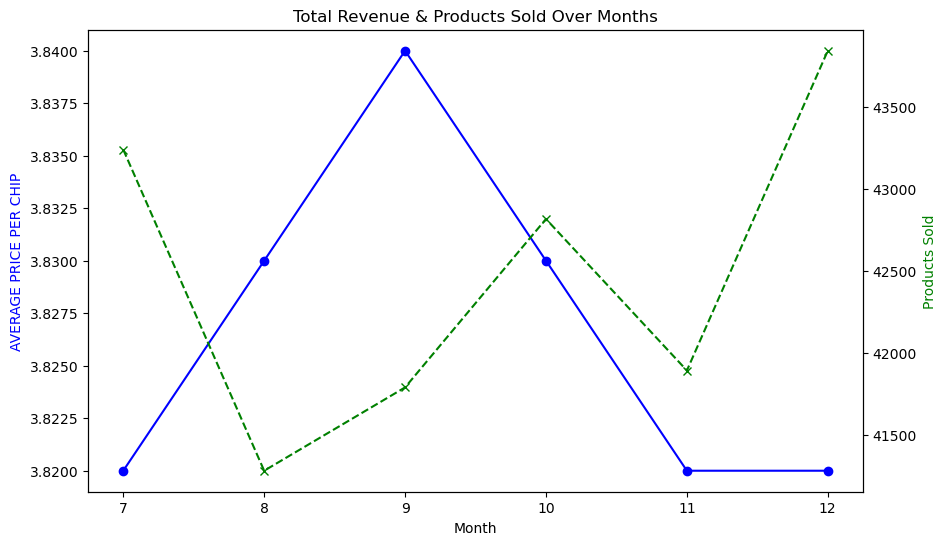

In [57]:
fig, ax1 = plt.subplots(figsize=(10,6))

# Plotting total revenue on the first y-axis (ax1)
ax1.plot(total_revenue['MONTH'], total_revenue['price_per_product'], color='blue', marker='o')
ax1.set_xlabel('Month')
ax1.set_ylabel('AVERAGE PRICE PER CHIP', color='blue')
ax1.tick_params(axis='y')

# Creating the second y-axis for products sold
ax2 = ax1.twinx()

# Plotting total products sold on the second y-axis (ax2)
ax2.plot(products_sold['MONTH'], products_sold['PROD_QTY'], color='green', marker='x', linestyle='--')
ax2.set_ylabel('Products Sold', color='green')
ax2.tick_params(axis='y')

# Adding a title and adjusting the layout
plt.title('Total Revenue & Products Sold Over Months')
plt.show()

In [58]:
#this indicates an overall trend of the prices reduced triggers brings a heavy purchasing in chips.

# lets checK the trend in 2019 as well

In [59]:
total_revenuee = year_19.groupby('MONTH')['price_per_product'].mean().round(2).reset_index()
total_revenuee

,MONTH,price_per_product
0,1,3.82
1,2,3.83
2,3,3.83
3,4,3.82
4,5,3.81
5,6,3.83


In [60]:
products_soldd = year_19.groupby('MONTH')['PROD_QTY'].sum().round(2).reset_index()
products_soldd

,MONTH,PROD_QTY
0,1,42501
1,2,39220
2,3,43347
3,4,41825
4,5,41100
5,6,41852


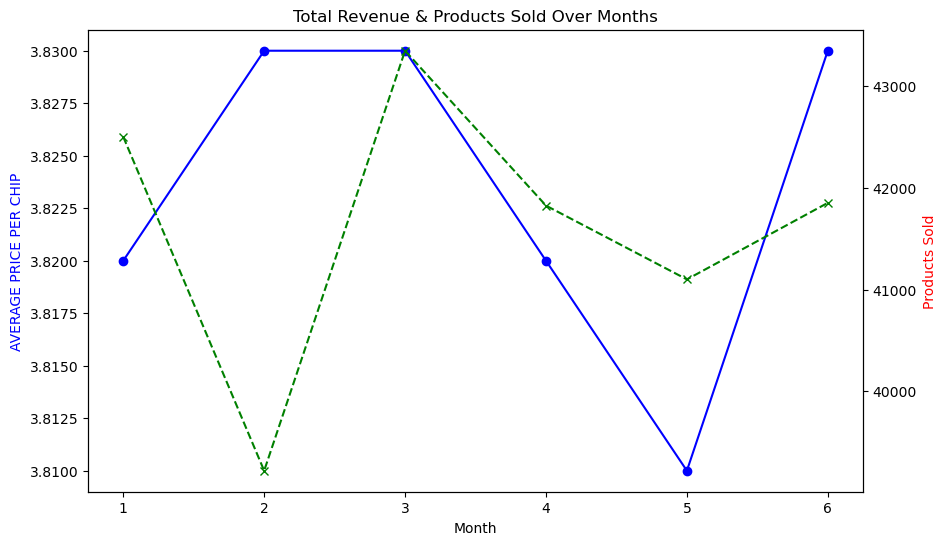

In [61]:
fig, ax1 = plt.subplots(figsize=(10,6))

# Plotting total revenue on the first y-axis (ax1)
ax1.plot(total_revenuee['MONTH'], total_revenuee['price_per_product'], color='blue', marker='o')
ax1.set_xlabel('Month')
ax1.set_ylabel('AVERAGE PRICE PER CHIP', color='blue')
ax1.tick_params(axis='y')

# Creating the second y-axis for products sold
ax2 = ax1.twinx()

# Plotting total products sold on the second y-axis (ax2)
ax2.plot(products_soldd['MONTH'], products_soldd['PROD_QTY'], color='green', marker='x', linestyle='--', label='Products Sold')
ax2.set_ylabel('Products Sold', color='red')
ax2.tick_params(axis='y')

# Adding a title and adjusting the layout
plt.title('Total Revenue & Products Sold Over Months')
plt.show()

In [66]:
merged_data.to_csv('/Users/ratikpant/Desktop/QUANTIUM PROJECT/merged_data.csv', index=False)

In [63]:
pwd

'/Users/ratikpant/Desktop'

In [62]:
#report

# Executive Summary:

You’ve done a thorough job analyzing chips sales from July 2018 to July 2019, combining transaction and customer data, and exploring trends across time, stores, product lines, and customer types. The findings reveal clear opportunities for targeted marketing, product promotion, and store-level strategy.


# 1. Customer Targeting & Loyalty Strategy
 Insight:
Older singles/couples & retirees dominate spending in both Mainstream and Premium segments.

Budget customers are spread across life stages, but older families spend the most here.

You’ve built total_spend and identified some high-spending but infrequent shoppers.
Recommendations:
Create loyalty programs targeted at Premium & Mainstream customers in older age groups.

Offer "win-back" promotions (e.g., 10% off next purchase) to high spenders with low frequency.

Build segment-specific bundles (e.g., larger pack sizes for older families, trendy flavors for young singles).

Launch a "Buy X, Get 1 Free" offer to increase frequency among less loyal but high-value customers.

# 2. Store-Level Strategy
Insight:
Store 226 consistently brings in the highest revenue, driven by high-quantity purchases (200 units in one order).

Store 211 had negligible sales — likely a data anomaly or inactive store.

 Recommendations:
For top-performing stores: Investigate if specific promotions, layouts, or demographics are driving high sales (esp. in Store 226).

For underperforming stores like Store 211:

Audit the data or store activity.

If valid, assess local competition or customer presence.

Roll out test promotions in low-performing stores to attract footfall.

# 3. Product Promotion Strategy
 Insight:
Products like Dorito Corn Chip Supreme 380g, Kettle Sweet Chilli & Sour Cream, and Grain Waves dominate sales consistently.

Monthly analysis shows some stable best-sellers across months, while others spike seasonally.

You noted only 2 anomalies in pricing with quantity 200 — good catch and correction.

Recommendations:
Continue stocking top 10 performers across all stores — prioritize these in end-aisle displays and flyers.

Use bundle deals for similar products (e.g., Doritos + Salsa dip) to raise avg basket size.

Promote seasonal best-sellers during peak months — use your monthly plots to time ads and discounts.

# 4 . Pricing Strategy & Sales Drivers
 Insight:
Your dual-axis plot (price vs quantity) shows: lower prices slightly increase volume, but price effect is minimal overall.

The average price stayed between $3.81–$3.84, while demand fluctuated due to other drivers (like month, product popularity).

 Recommendations:
Price sensitivity is low → avoid frequent discounts. Instead:

Run value-based marketing: “Gourmet Flavors at Everyday Prices”.

Emphasize portion size or healthier ingredients to justify stable pricing.

Only use discounts on new or underperforming products — not for best-sellers.

# 5. Metrics & Performance Monitoring
 Insight:
You’ve already built:

Total spend per customer

Monthly sales volume

Average price per product

Product quantity per customer

 Recommendations:
Automate these KPIs monthly for internal dashboards.

Use them to track campaign effectiveness (e.g., see if spend or frequency increases after a promo).